In [32]:
using MPSKit, TensorKit, Plots, LinearAlgebra, LaTeXStrings

In [33]:
d = 30 # local Hilbert space dimension
D = 64 # maximum bond dimension

64

In [34]:
phi_sq = zeros(ComplexF64, (d, d))
pi_sq = zeros(ComplexF64, (d, d))
phi_4 = zeros(ComplexF64, (d, d))
phi = zeros(ComplexF64, (d, d))

30×30 Matrix{ComplexF64}:
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im  …  0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
 0.0+0.0im  0.0+0.0im  0.0+0.0im     0.0+0.0im  0.0+0.0im  0.0+0.0im
    ⋮                             ⋱                        
 0.0+0.0im  0.0+0

In [35]:
for i in 2:d
    phi[i, i - 1] = sqrt(i / 2)
    phi[i - 1, i] = sqrt(i / 2)
end

In [36]:
for i in 1:d
    if i < d - 1
        phi_sq[i, i + 2] = sqrt(i * (i + 1)) / 2
        phi_sq[i + 2, i] = sqrt(i * (i + 1)) / 2
    end
    phi_sq[i, i] = (2 * i - 1) / 2
end
for i in 1:d
    if i < d - 1
        pi_sq[i, i + 2] = - sqrt(i * (i + 1)) / 2
        pi_sq[i + 2, i] = - sqrt(i * (i + 1)) / 2
    end
    pi_sq[i, i] = (2 * i - 1) / 2
end

In [37]:
for i in 1:d
    n = i - 1  # occupation number

    # diagonal
    phi_4[i, i] = (6 * n^2 + 6 * n + 3) / 4

    # connect |n> <-> |n+2>
    if i + 2 <= d
        val = (4 * n + 6) * sqrt((n + 1) * (n + 2)) / 4
        j = i + 2
        phi_4[i, j] = val
        phi_4[j, i] = val   # Hermitian
    end

    # connect |n> <-> |n+4>
    if i + 4 <= d
        val = sqrt((n + 1) * (n + 2) * (n + 3) * (n + 4)) / 4
        j = i + 4
        phi_4[i, j] = val
        phi_4[j, i] = val   # Hermitian
    end
end

In [38]:
ϕ2 = TensorMap(phi_sq, ℂ^d ← ℂ^d)
π2 = TensorMap(pi_sq, ℂ^d ← ℂ^d)
ϕ4 = TensorMap(phi_4, ℂ^d ← ℂ^d)
id = TensorMap(diagm(ComplexF64[1 for _ in 1:d]), ℂ^d ← ℂ^d)
ϕ = TensorMap(phi, ℂ^d ← ℂ^d)

30←30 TensorMap{ComplexF64, ComplexSpace, 1, 1, Vector{ComplexF64}}:
 codomain: ⊗(ℂ^30)
 domain: ⊗(ℂ^30)


In [39]:
μ0 = 0.3

0.3

In [40]:
L = 12

12

In [41]:
ψ = FiniteMPS(L, ℂ^d, ℂ^D)

12-site FiniteMPS (ComplexF64, ComplexSpace):
┌ C[12]: TensorMap{ComplexF64, ComplexSpace, 1, 1, Vector{ComplexF64}}(ComplexF64[1.0+0.0im], ℂ^1 ← ℂ^1)
├── AL[12]: TensorMap{ComplexF64, ComplexSpace, 2, 1, Vector{ComplexF64}}(ComplexF64[0.115605+0.139274im, 0.00492761+0.00784687im, 0.00509221+0.00591801im, 0.00171689+0.00254563im, 0.00115119+0.0022905im, -1.19721e-5+0.00123388im, 0.000840076+0.000786519im, 0.00123475+0.00153936im, 0.000940149+0.00168243im, 2.59734e-5+0.000779283im  …  0.000562536+6.53618e-5im, 0.000231403+0.000135849im, 0.000146289-0.000122949im, 0.000347666+0.000485026im, 0.0002048+0.00035359im, 0.000191899+0.000276629im, -9.77275e-5+0.000205214im, 0.000181731+0.000153946im, -3.46868e-5+0.000260538im, 0.000105208+0.000162406im], (ℂ^30 ⊗ ℂ^30) ← ℂ^1)
├── AL[11]: TensorMap{ComplexF64, ComplexSpace, 2, 1, Vector{ComplexF64}}(ComplexF64[0.146099+0.123968im, 0.00835445+0.00548057im, 0.00716197+0.00172235im, 0.00450221+0.00367212im, 0.00185097+0.00176885im, 0.00288576+0.0014

In [42]:
chain = fill(ℂ^d, L)

12-element Vector{ComplexSpace}:
 ℂ^30
 ℂ^30
 ℂ^30
 ℂ^30
 ℂ^30
 ℂ^30
 ℂ^30
 ℂ^30
 ℂ^30
 ℂ^30
 ℂ^30
 ℂ^30

In [43]:
L = 12 # number of lattice sites
max_bond_dimension = ℂ^D
physical_space = ℂ^d
ψ0 = FiniteMPS(rand, ComplexF64, L, physical_space, max_bond_dimension)

12-site FiniteMPS (ComplexF64, ComplexSpace):
┌ C[12]: TensorMap{ComplexF64, ComplexSpace, 1, 1, Vector{ComplexF64}}(ComplexF64[1.0+0.0im], ℂ^1 ← ℂ^1)
├── AL[12]: TensorMap{ComplexF64, ComplexSpace, 2, 1, Vector{ComplexF64}}(ComplexF64[0.125781+0.122657im, 0.0054871+0.00622729im, 0.0050187+0.00308174im, 0.0020984+0.000990988im, 0.0029466+0.00041514im, 0.00161495+0.00164422im, 2.06228e-5+0.000289906im, 0.00142675+0.00137264im, 0.00134085+0.00128926im, 0.000560779+0.00109575im  …  0.000336544+0.000615577im, 0.000272384+7.09193e-5im, 0.000204162+0.000239755im, -0.000334922+0.000188595im, 0.000334014+0.000237294im, 8.50519e-5+0.00021805im, 6.81125e-5+0.000256749im, 0.000128868-3.63634e-5im, 0.000291858+0.000108325im, 0.000118825+7.94018e-6im], (ℂ^30 ⊗ ℂ^30) ← ℂ^1)
├── AL[11]: TensorMap{ComplexF64, ComplexSpace, 2, 1, Vector{ComplexF64}}(ComplexF64[0.126136+0.131623im, 0.00614471+0.00510912im, 0.00220914+0.00479776im, 0.00176342+0.000780025im, 0.00118739+0.00270753im, 0.00223721+0.00267312i

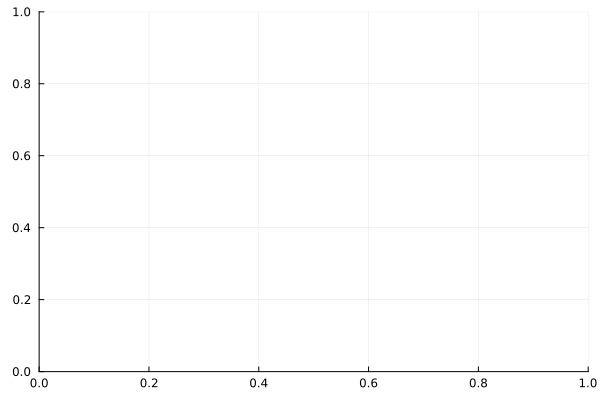

In [44]:
kappa_grid = 10
lam_grid = 5

kappa_max = kappa_grid * 0.1
lam_max = lam_grid * 0.2

plt = plot()

In [ ]:
for i in 0:lam_grid - 1
    entropy_vec = zeros(Float64, kappa_grid)
    λ = 0.2 * i
    for j in 1:kappa_grid
        κ = 0.1 * (j - 1)
        println("Currently working with λ = $λ and κ = $κ")
        phi_sq_terms = [i => (μ0^2 / 2 + κ) * ϕ2 for i in 1:L]
        phi_4_terms = [i => (λ / 24) * ϕ4 for i in 1:L]
        pi_sq_terms = [i => 0.5 * π2 for i in 1:L]
        single_site_terms = [phi_sq_terms; phi_4_terms; pi_sq_terms]
        two_site_terms = [(i, i + 1) => -κ * ϕ ⊗ ϕ for i in 1:L - 1]
        H_phi_4_finite = FiniteMPOHamiltonian(chain, single_site_terms..., two_site_terms...)
        ψ0 = FiniteMPS(L, ℂ^d, ℂ^D)
        ψ, _, _ = find_groundstate(ψ0, H_phi_4_finite, DMRG2(;trscheme=truncrank(40), maxiter=20, tol=1e-7))
        entropy_vec[j] = entropy(ψ, 6)
    end
    plot!(0.1 * [0:kappa_grid - 1], entropy_vec, label=L"\lambda = %$(round(λ, digits=1))")
    xlabel!(L"\kappa")
    ylabel!(L"S_{1/2}")
end

In [ ]:
display(plt)